# Stable Diffusion

In [16]:
import requests
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms, utils
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Componentes

In [17]:
model_id = "CompVis/stable-diffusion-v1-4"

tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)

In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print(f"CLIP Text Encoder: {count_parameters(text_encoder)} parámetros.")
print(f"VAE: {count_parameters(vae)} parámetros.")
print(f"U-Net: {count_parameters(unet)} parámetros.")


CLIP Text Encoder: 123060480 parámetros.
VAE: 83653863 parámetros.
U-Net: 859520964 parámetros.


### CLIP Text encoder

In [19]:
def cosine_similarity(p1, p2, tokenizer, encoder):
    inputs = tokenizer([p1, p2], return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        embeddings = encoder(**inputs).pooler_output
        embeddings = F.normalize(embeddings, dim=1)
    similarity = torch.sum(embeddings[0] * embeddings[1]).item()
    return similarity

# Prompts:
prompt_a = "A photo of a red sports car driving on a mountain road"
prompt_b = "A photograph of a luxury car speeding on a hill highway"
prompt_c = "A portrait of a medieval queen in oil painting style"

# Similitud:
sim_ab = cosine_similarity(prompt_a, prompt_b, tokenizer, text_encoder)
sim_ac = cosine_similarity(prompt_a, prompt_c, tokenizer, text_encoder)
sim_bc = cosine_similarity(prompt_b, prompt_c, tokenizer, text_encoder)

print(f"Similitud(a, b): {sim_ab:.4f}")
print(f"Similitud(a, c): {sim_ac:.4f}")
print(f"Similitud(b, c): {sim_bc:.4f}")

Similitud(a, b): 0.6739
Similitud(a, c): 0.1487
Similitud(b, c): 0.1718


### VAE

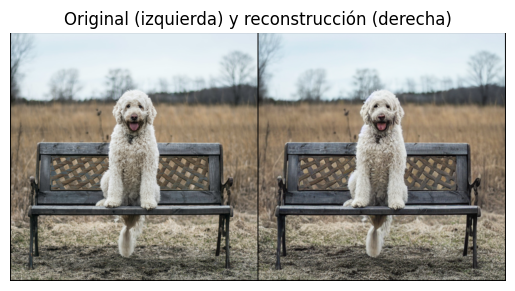

In [20]:
def load_image_from_url(url, size=(512, 512), mode="RGB"):
    img = Image.open(requests.get(url, stream=True).raw).convert(mode)
    img = img.resize(size, Image.BICUBIC)
    return img

def preprocess(img_pil):
    to_tensor = transforms.ToTensor()
    x = to_tensor(img_pil).unsqueeze(0).to(device)
    return 2.0 * x - 1.0

# Ejemplo:
image_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
img_pil = load_image_from_url(image_url)
x = preprocess(img_pil)

# Reconstrucción:
with torch.no_grad():
    z = vae.encode(x).latent_dist.sample()
    x_rec = vae.decode(z).sample
    x_rec = (x_rec.clamp(-1, 1) + 1) / 2

# Visualización:
grid = utils.make_grid(torch.cat([x.clamp(-1,1).add(1).div(2), x_rec], dim=0), nrow=2)
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.axis("off")
plt.title("Original (izquierda) y reconstrucción (derecha)")
plt.show()

### U-Net

In [21]:
batch_size = 1
latent_channels = 4
height = width = 64
context_dim = 768

# Tensores aleatorios:
z_t = torch.randn(batch_size, latent_channels, height, width).to(device)
t = torch.tensor([50]).to(device)
context = torch.randn(batch_size, 77, context_dim).to(device)

# Forward:
with torch.no_grad():
    output = unet(z_t, t, encoder_hidden_states=context)

assert output["sample"].shape == (batch_size, latent_channels, height, width)

## Denoising

### DDIM Scheduler

In [22]:
n_steps = 50
scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler")
scheduler.set_timesteps(n_steps, device=device)

### Generación condicional simple

In [23]:
def vae_decode(latents, plot_title):

    with torch.no_grad():
        latents_scaled = latents / vae.config.scaling_factor
        image = vae.decode(latents_scaled).sample
        image = (image.clamp(-1, 1) + 1) / 2

        grid = utils.make_grid(image, nrow=1)
        plt.imshow(grid.cpu().permute(1, 2, 0))
        plt.axis("off")
        plt.title(plot_title)
        plt.show()

In [24]:
def generate_sample(prompt):

    text_input = tokenizer([prompt], return_tensors="pt", padding=True, truncation=True)
    text_embeddings = text_encoder(text_input.input_ids.to(device))[0]

    latents = torch.randn((1, 4, 64, 64), device=device)
    latents = latents * scheduler.init_noise_sigma

    for step, t in enumerate(scheduler.timesteps, 1):
        latent_model_input = scheduler.scale_model_input(latents, t)

        with torch.no_grad():
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings)["sample"]

        latents = scheduler.step(noise_pred, t, latents)["prev_sample"]

        if step % 10 == 0 or step == n_steps:
            vae_decode(latents, plot_title=f"Step {step}/{n_steps}")

    vae_decode(latents, plot_title="Imagen generada")

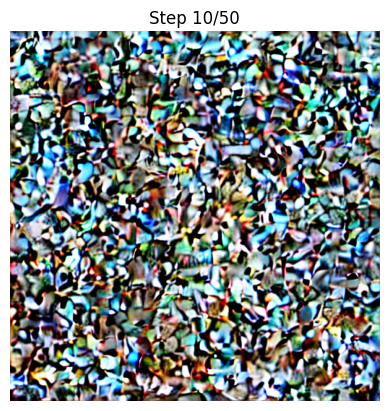

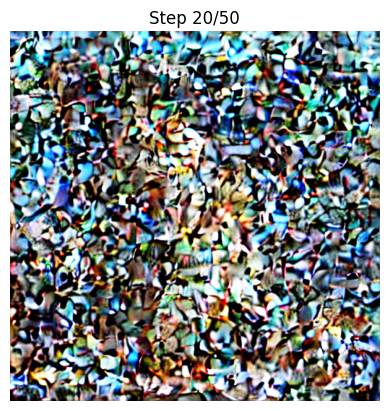

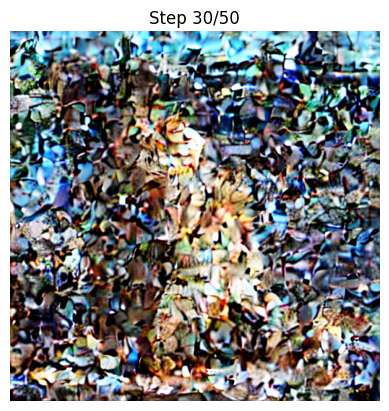

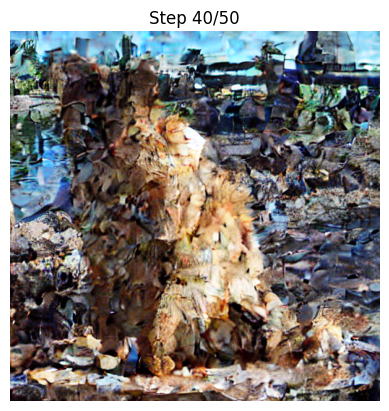

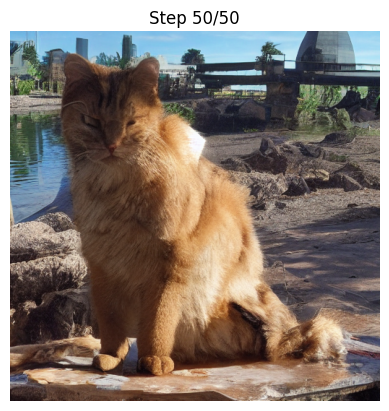

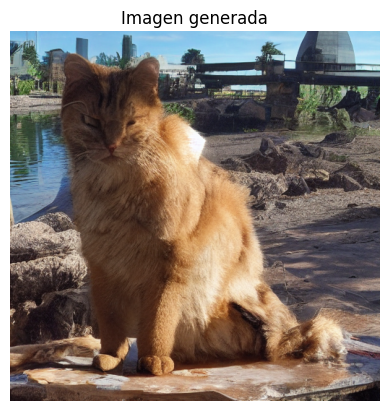

In [25]:
prompt = "A yellow cat sitting on a park bench"
generate_sample(prompt)

### Classifier-free guidance

In [26]:
def generate_sample_guidance(prompt, guidance_scale):

    text_input = tokenizer([prompt], return_tensors="pt", padding="max_length", truncation=True, max_length=tokenizer.model_max_length)
    text_embeddings = text_encoder(text_input.input_ids.to(device))[0]

    if guidance_scale > 0:
        uncond_input = tokenizer([""], return_tensors="pt", padding="max_length", truncation=True, max_length=tokenizer.model_max_length)
        uncond_embeddings = text_encoder(uncond_input.input_ids.to(device))[0]
        context_embeddings = torch.cat([uncond_embeddings, text_embeddings])
    else:
        context_embeddings = text_embeddings

    latents = torch.randn((1, 4, 64, 64), device=device)
    scheduler.set_timesteps(n_steps, device=device)
    latents = latents * scheduler.init_noise_sigma

    for step, t in enumerate(scheduler.timesteps, 1):
        if guidance_scale > 0:
            latent_model_input = torch.cat([latents] * 2)
        else:
            latent_model_input = latents

        latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        with torch.no_grad():
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=context_embeddings)["sample"]

        if guidance_scale > 0:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        latents = scheduler.step(noise_pred, t, latents)["prev_sample"]

        if step % 10 == 0 or step == n_steps:
            vae_decode(latents, plot_title=f"Step {step}/{n_steps} (guidance={guidance_scale})")

    vae_decode(latents, plot_title=f"Imagen generada (guidance={guidance_scale})")

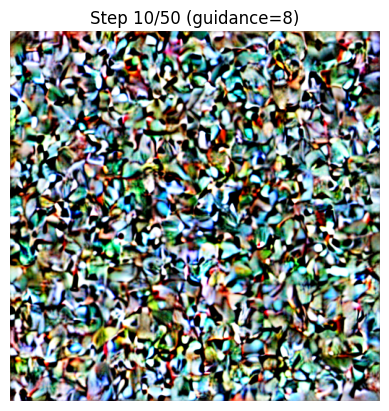

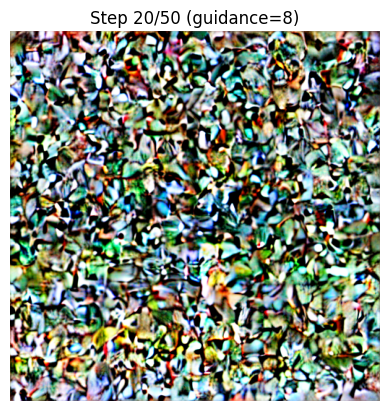

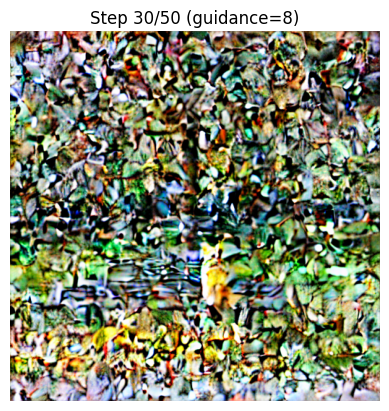

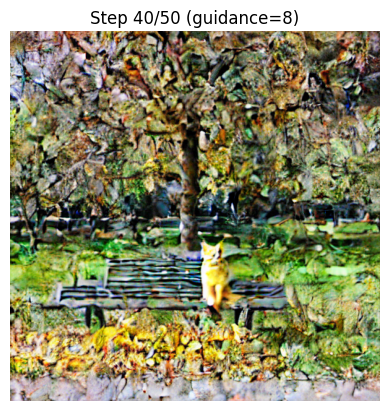

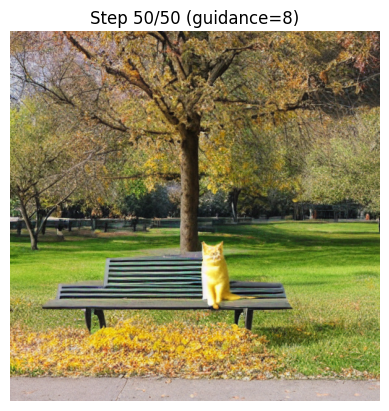

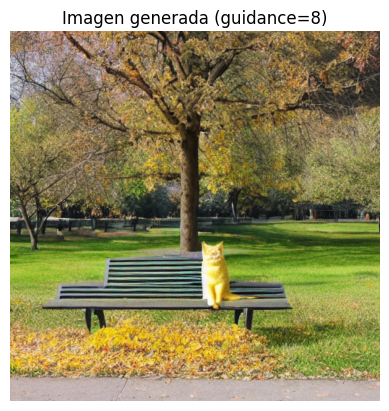

In [27]:
prompt = "A yellow cat sitting on a park bench"
generate_sample_guidance(prompt, guidance_scale=8)

## Inpainting

In [28]:
def inpainting(prompt, image, mask, guidance_scale):

    image_tensor = preprocess(image)
    mask_tensor  = transforms.ToTensor()(mask).unsqueeze(0).to(device)

    x = image_tensor
    m = mask_tensor

    with torch.no_grad():
        z0 = vae.encode(x).latent_dist.sample() * vae.config.scaling_factor

    m_lat = torch.nn.functional.interpolate(m, size=(64, 64), mode="nearest").round()
    m_lat = m_lat.expand(-1, 4, -1, -1)

    text_input = tokenizer([prompt], padding="max_length", max_length=tokenizer.model_max_length, return_tensors="pt")
    text_embeddings = text_encoder(text_input.input_ids.to(device))[0]
    uncond_input = tokenizer([""], padding="max_length", max_length=tokenizer.model_max_length, return_tensors="pt")
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(device))[0]
    context = torch.cat([uncond_embeddings, text_embeddings], dim=0)

    eps_base = torch.randn_like(z0)
    latents = torch.randn_like(z0) * scheduler.init_noise_sigma

    for step, t in enumerate(scheduler.timesteps, 1):
        inp = torch.cat([latents, latents], dim=0)
        inp = scheduler.scale_model_input(inp, t)

        with torch.no_grad():
            noise_pred = unet(inp, t, encoder_hidden_states=context)["sample"]
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        latents = scheduler.step(noise_pred, t, latents)["prev_sample"]

        z0_noised = scheduler.add_noise(z0, eps_base, timesteps=t)
        latents = m_lat * latents + (1 - m_lat) * z0_noised

        if step % 10 == 0 or step == n_steps:
            vae_decode(latents, plot_title=f"Step {step}/{n_steps} (guidance={guidance_scale})")

    latents = m_lat * latents + (1 - m_lat) * z0
    vae_decode(latents, plot_title=f"Imagen generada (guidance={guidance_scale})")

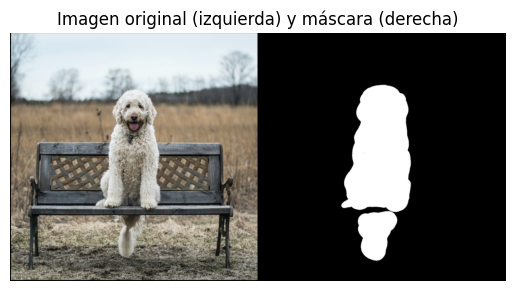

In [29]:
image_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

image = load_image_from_url(image_url, mode="RGB")
mask = load_image_from_url(mask_url,  mode="L")

# Visualización de la imagen basal y máscara:
to_tensor = transforms.ToTensor()
image_tensor = to_tensor(image)
mask_tensor = to_tensor(mask)
mask_tensor = mask_tensor.expand(3, -1, -1)
grid = utils.make_grid([image_tensor, mask_tensor], nrow=2)
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Imagen original (izquierda) y máscara (derecha)")
plt.show()

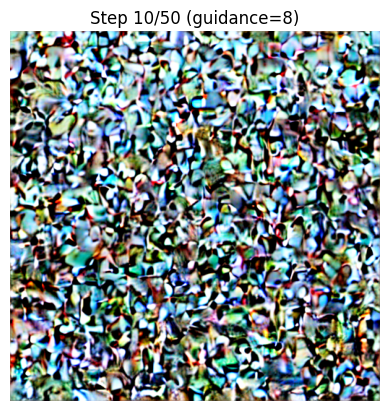

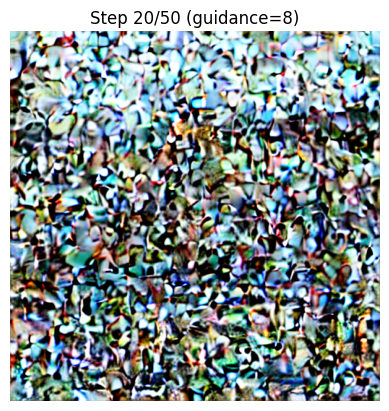

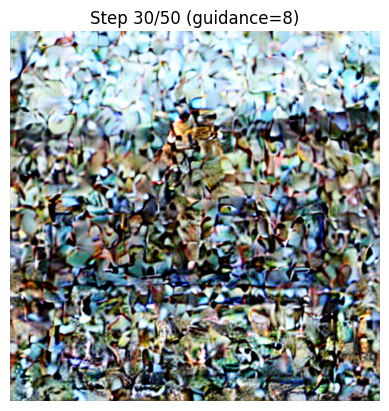

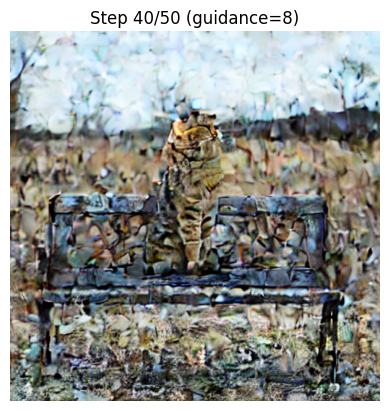

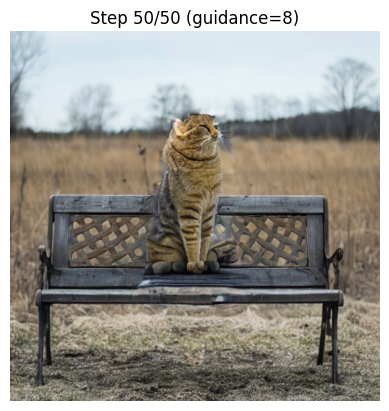

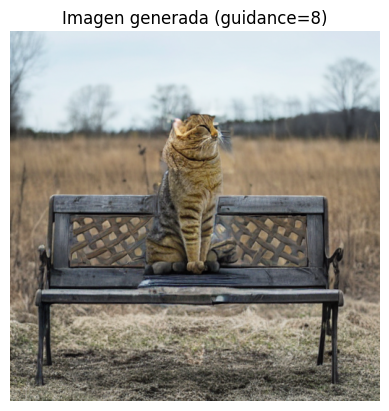

In [31]:
prompt = "A yellow cat sitting on a park bench"
inpainting(prompt, image, mask, guidance_scale=8)